# LSTM

## Introduction to LSTMs for Natural Language Processing

Long Short-Term Memory (LSTM) networks are a special kind of Recurrent Neural Network (RNN) capable of learning long-term dependencies. They were introduced to address the vanishing gradient problem that standard RNNs face, which makes them highly effective for sequential data like text.

In Natural Language Processing (NLP), LSTMs have been foundational for tasks such as sentiment analysis, machine translation, speech recognition, and text generation, due to their ability to remember important information over long sequences.

### Why LSTMs over traditional RNNs?

Traditional RNNs struggle with long-term dependencies because the gradient of the loss function with respect to the weights can vanish or explode over many time steps. This means that information from earlier parts of the sequence gets lost by the time it reaches the later parts, or gradients become too large to handle.

LSTMs mitigate this problem through a sophisticated internal structure called a 'cell state' and various 'gates' that regulate the flow of information.

### The Core Components of an LSTM Cell

An LSTM unit consists of a **cell state** (or *memory cell*) and three main **gates**: the **forget gate**, the **input gate**, and the **output gate**. These gates are composed of a sigmoid neural net layer and a pointwise multiplication operation.

<img src="https://miro.medium.com/max/1400/1*rQ-9F2-u2z8X7ZzL_gQ3Yg.png" width="600" alt="LSTM Cell Diagram">

*Source: Christopher Olah's blog on LSTMs (colah.github.io/posts/2015-08-Understanding-LSTMs/)*

#### 1. The Forget Gate ($f_t$)

This gate decides what information from the previous cell state ($C_{t-1}$) should be thrown away or kept. It outputs a number between 0 and 1 for each number in the cell state $C_{t-1}$. A 1 means "completely keep this", while a 0 means "completely forget this".

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

Where:
- $x_t$ is the input at the current time step.
- $h_{t-1}$ is the hidden state from the previous time step.
- $W_f$ and $b_f$ are the weight matrix and bias for the forget gate.
- $\sigma$ is the sigmoid function.

#### 2. The Input Gate ($i_t$) and Candidate Cell State ($\tilde{C}_t$)

This gate decides what new information should be stored in the cell state. It has two parts:
1.  A sigmoid layer (input gate layer) decides which values to update.
    $$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
2.  A tanh layer creates a vector of new candidate values ($\tilde{C}_t$) that could be added to the state.
    $$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

These two are then combined to update the cell state.

#### 3. Updating the Cell State ($C_t$)

Now, the old cell state ($C_{t-1}$) is updated into the new cell state ($C_t$).

$$C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t$$

This is where the magic happens: the forget gate ($f_t$) multiplies the old state ($C_{t-1}$), dropping parts we decided to forget. Then, the input gate ($i_t$) multiplies the candidate values ($\tilde{C}_t$), adding the new information we decided to keep. This linear interaction (addition) is crucial for preventing vanishing gradients.

#### 4. The Output Gate ($o_t$)

Finally, this gate decides what part of the cell state ($C_t$) we're going to output as the hidden state ($h_t$).

First, a sigmoid layer determines which parts of the cell state will be output.
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

Then, the cell state is put through a tanh (to push the values between -1 and 1) and multiplied by the output of the sigmoid gate.
$$h_t = o_t \cdot \tanh(C_t)$$

The hidden state $h_t$ is used for predictions and is passed to the next time step.

## Practical Example: Text Classification with Keras and LSTMs

Let's demonstrate how to use LSTMs for a simple text classification task, such as sentiment analysis. We'll use a dummy dataset for simplicity.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# 1. Prepare Dummy Data
# Let's create some simple text data for sentiment analysis (positive/negative)
documents = [
    "This movie was fantastic, I loved it!",
    "Great acting and an engaging plot.",
    "Horrible film, a complete waste of time.",
    "The worst movie I've seen in years, so boring.",
    "A truly enjoyable experience, highly recommend.",
    "Not good, I would not watch again."
]

# Labels: 1 for positive, 0 for negative
labels = np.array([1, 1, 0, 0, 1, 0])

print("Original documents:")
for doc, label in zip(documents, labels):
    print(f"  '{doc}' -> Label: {label}")


In [ ]:
# 2. Tokenization and Padding
# Tokenization converts words into numerical IDs
tokenizer = Tokenizer(num_words=100, oov_token="<unk>") # max 100 unique words, use <unk> for unknown words
tokenizer.fit_on_texts(documents)

word_index = tokenizer.word_index
print(f"\nTotal unique words found: {len(word_index)}")
print(f"Sample word_index: {list(word_index.items())[:10]}")

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(documents)
print(f"\nSequences after tokenization: {sequences}")

# Pad sequences to ensure uniform length for input to the LSTM
# The maximum length of a sequence in our dataset
max_sequence_length = max([len(x) for x in sequences])

padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post')

print(f"\nMax sequence length: {max_sequence_length}")
print(f"Padded sequences:\n{padded_sequences}")


In [ ]:
# 3. Build the LSTM Model

vocabulary_size = len(tokenizer.word_index) + 1 # +1 for padding/OOV token
embedding_dim = 16 # Dimension of the word embeddings

model = Sequential([
    # Embedding layer converts integer sequences to dense vectors of fixed size
    Embedding(input_dim=vocabulary_size, output_dim=embedding_dim, input_length=max_sequence_length),
    # LSTM layer processes the sequence data
    LSTM(units=32), # 32 LSTM units (neurons) in the layer
    # Dense output layer for binary classification (sentiment: positive/negative)
    Dense(units=1, activation='sigmoid') # Sigmoid for binary classification output (0 or 1)
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()


In [ ]:
# 4. Train the Model

# For a real application, you would split your data into training and testing sets.
# Here, for demonstration, we'll train on the full small dataset.
epochs = 50
history = model.fit(
    padded_sequences,
    labels,
    epochs=epochs,
    verbose=0 # Set verbose to 1 or 2 to see training progress
)

print(f"Training finished after {epochs} epochs.")
# Evaluate the model on the training data
loss, accuracy = model.evaluate(padded_sequences, labels, verbose=0)
print(f"\nFinal Training Loss: {loss:.4f}")
print(f"Final Training Accuracy: {accuracy:.4f}")


In [ ]:
# 5. Make a Prediction

# New unseen text to predict sentiment
new_texts = [
    "This was an amazing experience, truly captivating.",
    "Utterly terrible and boring."
]

# Tokenize and pad the new text
new_sequences = tokenizer.texts_to_sequences(new_texts)
new_padded_sequences = pad_sequences(new_sequences, maxlen=max_sequence_length, padding='post')

# Predict sentiment
predictions = model.predict(new_padded_sequences)

print("\n--- Predictions ---")
for i, text in enumerate(new_texts):
    sentiment = "Positive" if predictions[i][0] > 0.5 else "Negative"
    print(f"'{text}' -> Predicted Sentiment: {sentiment} (Score: {predictions[i][0]:.4f})")


## Conclusion

This example demonstrates the fundamental steps of using an LSTM for a text classification task. LSTMs are powerful tools for NLP due to their ability to process sequential data and capture long-term dependencies. For more complex tasks, you would typically use larger datasets, more sophisticated preprocessing, pre-trained word embeddings (like Word2Vec, GloVe), and deeper or bidirectional LSTM architectures.

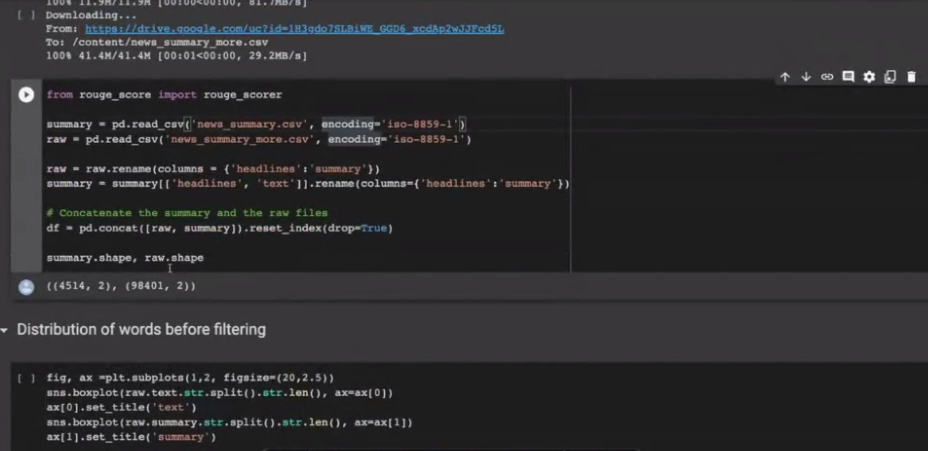

In [ ]:
fig.show()

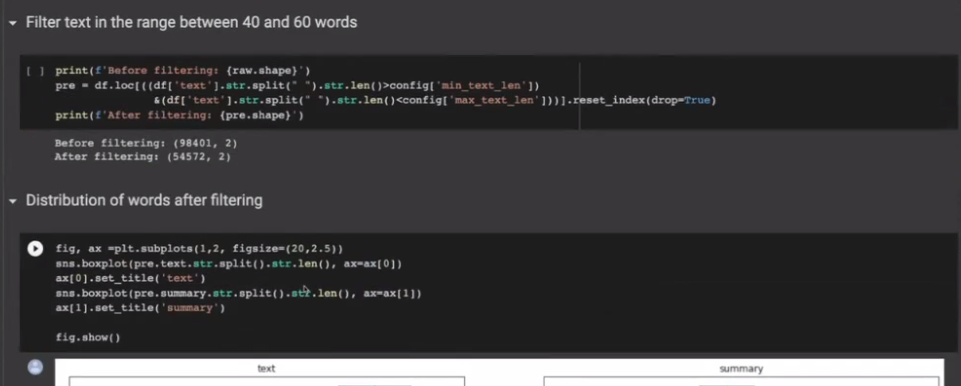

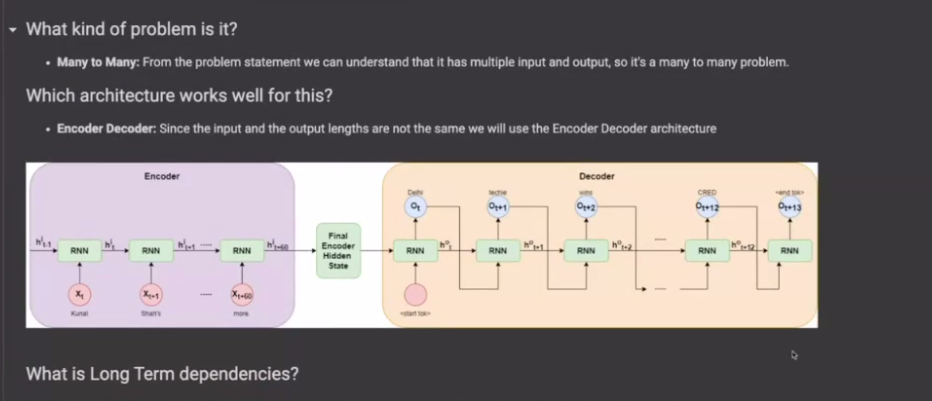

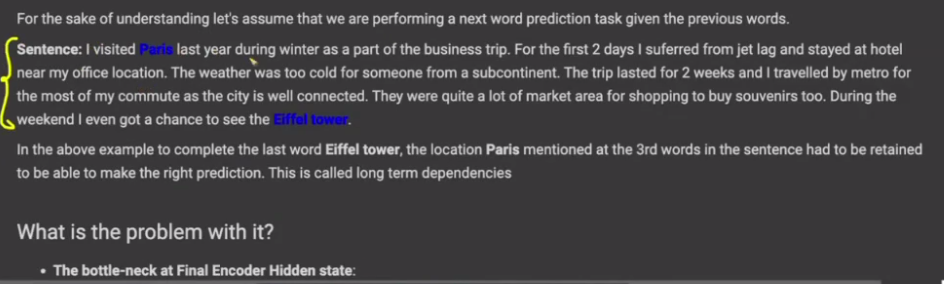

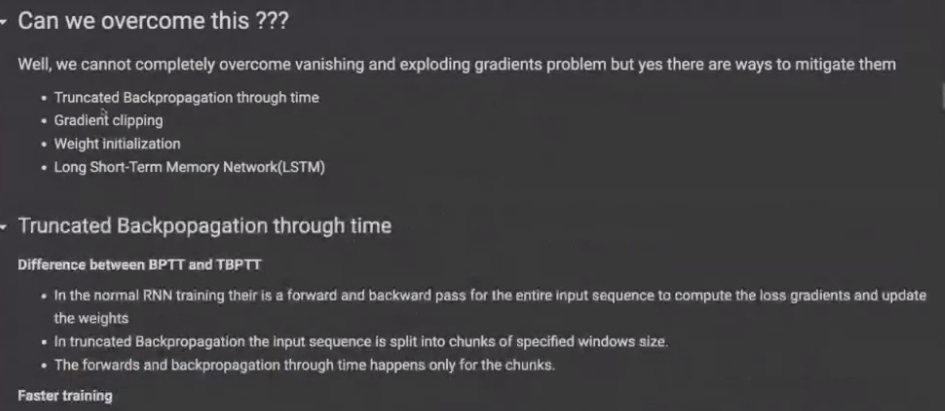

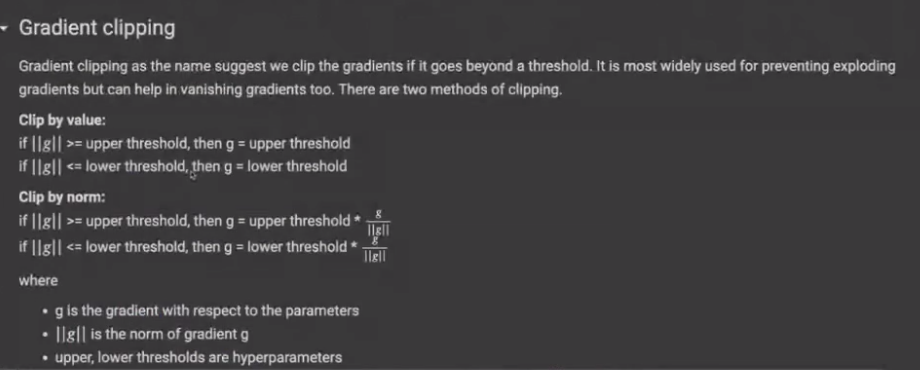

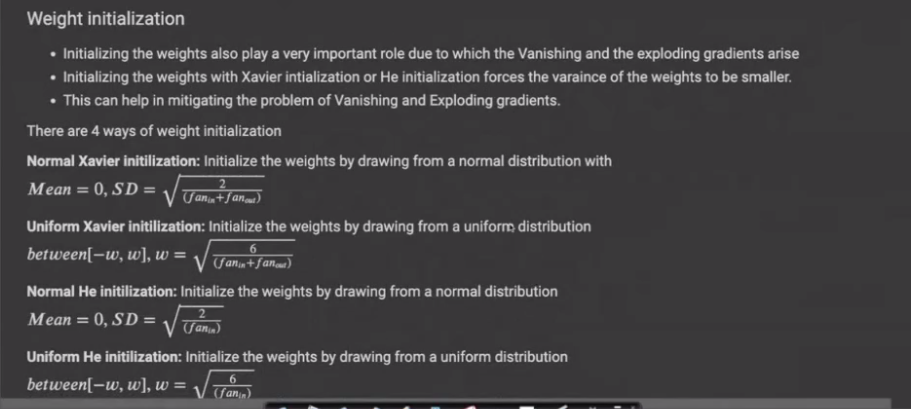

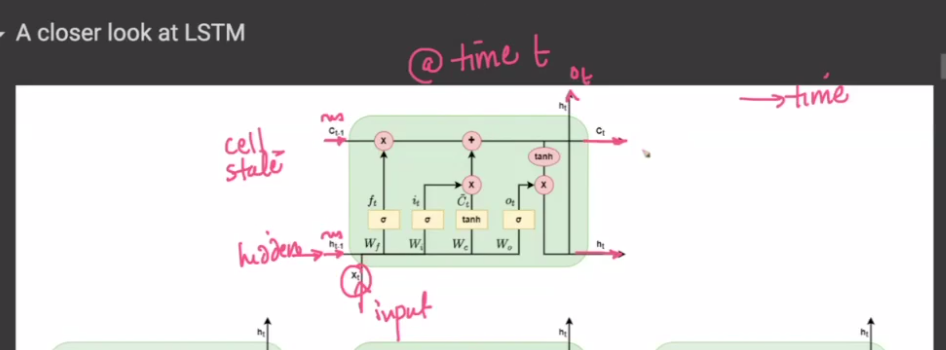

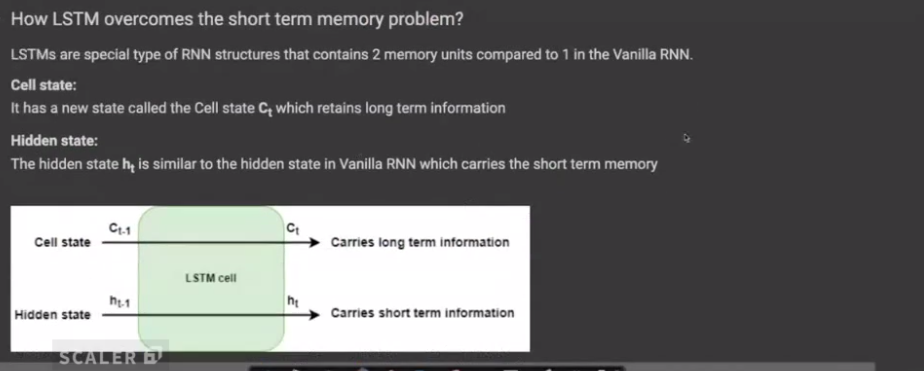

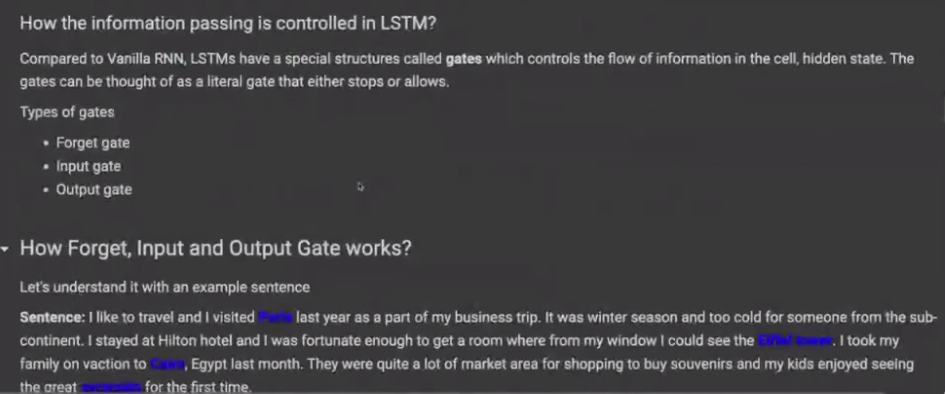

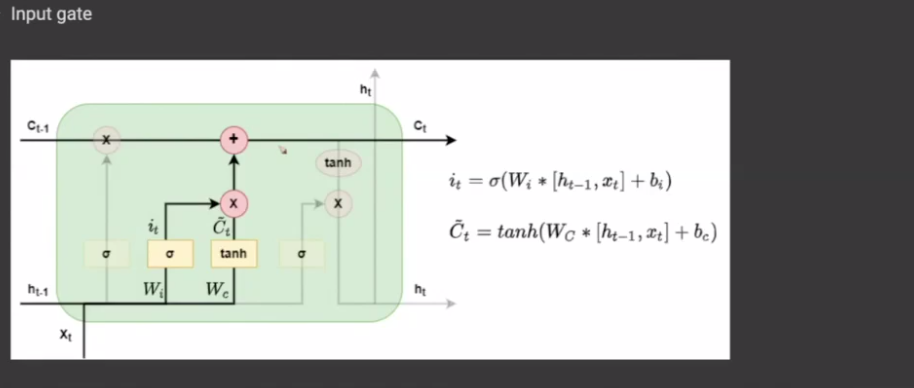

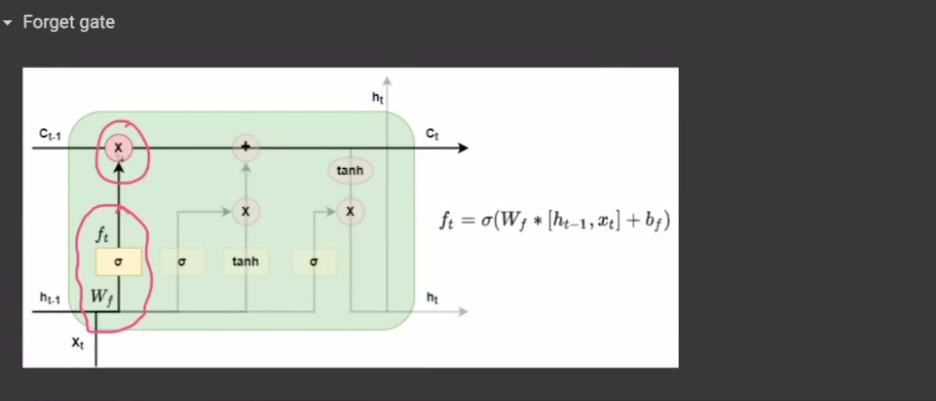

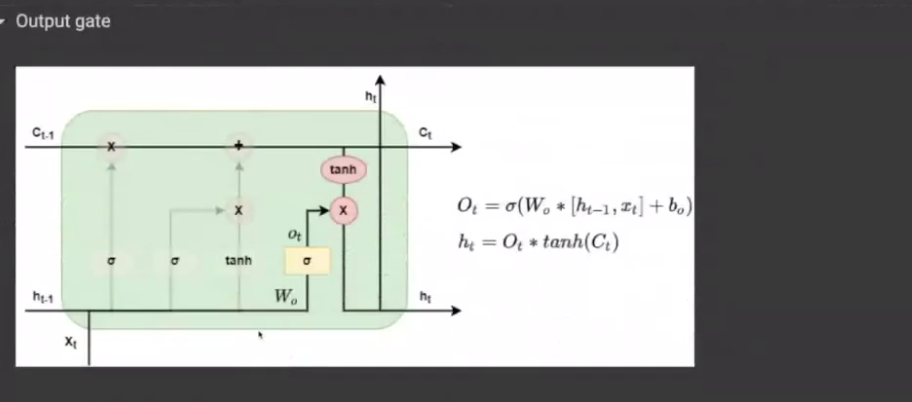

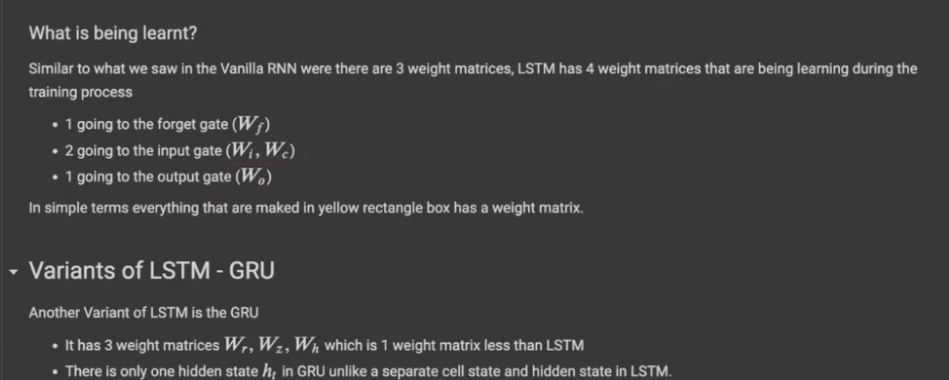

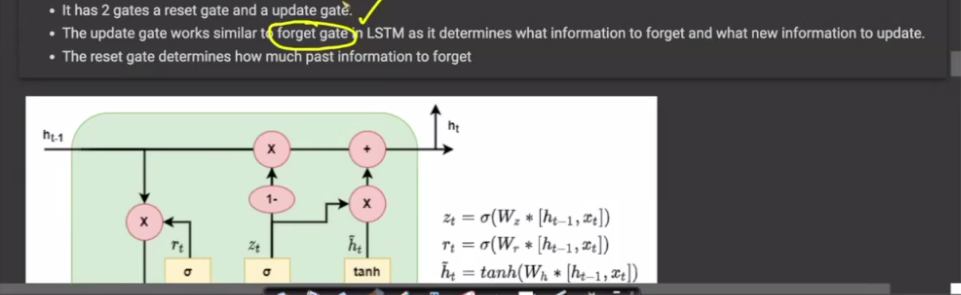